# Lesson 3: The `xarray` Library

## 🗃️ Libraries

In [1]:
# Attempting to use the `math` libray before importing
math.factorial(3)

NameError: name 'math' is not defined

In [2]:
# Import the Python library
import math

In [3]:
# Attempt #2 to use the `math` libray (after importing)
math.factorial(3)

6

## Data Cubes

_Code below used to illustrate a concept. It's not that important that you understand how the lists were made_

In [4]:
# 1D Python data
water_temp = [15, 64, 23, 42, 34]

print("Third temperature value:", water_temp[2])

Third temperature value: 23


In [5]:
# 2D Python data
sst = [[15, 64, 23, 400], [304, 305, 300, 410]]

print("One temperature value:", sst[1][2])

One temperature value: 300


In [6]:
co2 = [[[15, 64, 23, 400], [304, 305, 300, 410]], [[15, 64, 23, 400], [304, 305, 300, 410]]]

print("One CO2 value:", co2[0][1][3])

One CO2 value: 410


In [7]:
fourD = [[[[14, 15, 15], [34, 34, 34]], [[14, 15, 15], [34, 34, 34]]], [[[14, 15, 15], [34, 34, 34]], [[14, 15, 15], [34, 34, 34]]]]

In [8]:
print("One CO2 value:", fourD[1][0][1][2])

One CO2 value: 34


Does that long line of a list of a list of a list of a list look pretty ugly and hard to navigate to you? Good. Then you'll appreciate the benefit of xarray.

## Gridded data and `xarray`

In [9]:
import xarray as xr

In [ ]:
# Data values: first example data structure
air_temps = [
    [80, 80, 81, 83, 82, 80], [81, 80, 81, 83, 83, 82], [81, 81, 83, 84, 84, 83], 
    [79, 80, 83, 85, 85, 85], [78, 77, 80, 85, 86, 87]
]
# Coordinate values
lats = [36, 37, 38, 39, 40]
lons = [-80, -79, -78, -77, -76, -75]
# Assemble the DataArray
temps = xr.DataArray(data=air_temps, dims=['latitude', 'longitude'], coords=[lats, lons],)

In [ ]:
# Can we see what this represents?
temps

<xarray.DataArray (latitude: 5, longitude: 6)> Size: 240B
array([[80, 80, 81, 83, 82, 80],
       [81, 80, 81, 83, 83, 82],
       [81, 81, 83, 84, 84, 83],
       [79, 80, 83, 85, 85, 85],
       [78, 77, 80, 85, 86, 87]])
Coordinates:
  * latitude   (latitude) int64 40B 36 37 38 39 40
  * longitude  (longitude) int64 48B -80 -79 -78 -77 -76 -75

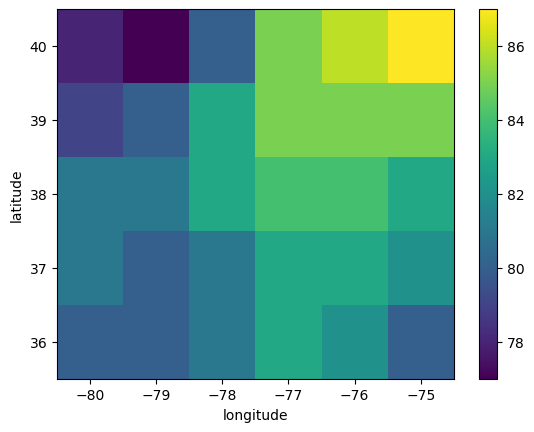

In [12]:
temps.plot()

If we were to summarize the fake data we just made, we could say that we made data showing: 

> air temperature values over Virginia and Maryland

:::{admonition} 📝 Check your understanding
:class: tip

The following `DataArray` contains values for wind speeds. How many dimensions does this DataArrray have? What is the shape of the data? What is the highest and lowest wind speed in the array? What data variables do the dimensions represent?

:::

In [ ]:
# wind_speed = np.random.randint(0, high=80, size=(5, 3))
# wind_speed = [[8, 12,7 ], [40, 42, 37], [71, 71, 80,], [106, 98, 111],]
# pressure = [1000, 750, 500, 350]
# lons = [-80, -79, -78]
# wind_speed = xr.DataArray(wind_speed, dims=['pressure', 'longitude'], coords=[pressure, lons])

# wind_speed

### Attributes/Properties

In [13]:
print('DIMS', temps.dims)
print('COORDS', temps.coords)
print('DATA', temps.data)

DIMS ('latitude', 'longitude')
COORDS Coordinates:
  * latitude   (latitude) int64 40B 36 37 38 39 40
  * longitude  (longitude) int64 48B -80 -79 -78 -77 -76 -75
DATA [[80 80 81 83 82 80]
 [81 80 81 83 83 82]
 [81 81 83 84 84 83]
 [79 80 83 85 85 85]
 [78 77 80 85 86 87]]


> Objects -> Nouns;
> 
> Functions -> Verbs;
> 
> Attributes/Properties -> Adjectives

## 3D Array Example

In [14]:
import numpy as np

In [ ]:
# Define the data (not important to understand this code)
temperature_3d_values = np.random.randint(0, high=75, size=(3, 4, 6))

# Define the coordinates
altitude = [0, 500, 1000]
lats = [33, 34, 35, 36]
lons = [-122, -121, -120, -119, -118, -117]

# Assemble the DataArray
temperature_3d = xr.DataArray(temperature_3d_values, 
                      dims=['altitude', 'latitude', 'longitude'], 
                      coords=[altitude, lats, lons]
                     )
temperature_3d

<xarray.DataArray (altitude: 3, latitude: 4, longitude: 6)> Size: 576B
array([[[11, 19, 35, 33, 52, 49],
        [36, 67, 20, 51,  8,  3],
        [ 4, 19, 18,  4, 56,  7],
        [18, 64, 39, 25,  5, 46]],

       [[26, 69, 10, 13, 57, 61],
        [13, 13, 57, 52, 13, 16],
        [ 9, 29, 50, 66, 19, 51],
        [64, 48, 18, 25, 50, 15]],

       [[53, 57, 33, 35, 64, 38],
        [38, 45, 15, 47, 45, 55],
        [56, 40,  4,  1, 42, 73],
        [42, 37, 67, 35, 45, 53]]])
Coordinates:
  * altitude   (altitude) int64 24B 0 500 1000
  * latitude   (latitude) int64 32B 33 34 35 36
  * longitude  (longitude) int64 48B -122 -121 -120 -119 -118 -117

## Practice

### Practice 1

Run the code below that creates a ocean salinity DataArray called `salinity`. 

A) Print the `salinity` DataArray

B) Draw a picture for yourself visualizing what this data represents. Include (and label) the data array, and the dimensions.

In [ ]:
salinity_values = np.random.randint(0, high=35, size=(4, 5, 6))

# Define the coordinates
depth_levels = [0, 5, 10, 15]
lats = [24, 25, 26, 27, 28]
lons = [-95, -94, -93, -92, -91, -90]

# Assemble the DataArray
salinity = xr.DataArray(salinity_values, 
                      dims=['depth', 'latitude', 'longitude'], 
                      coords=[depth_levels, lats, lons]
                     )

NameError: name 'np' is not defined

### Practice Challenge

Run the code below that creates a ocean salinity DataArray called `plant_cover`. 

A) Print the `plant_cover` DataArray

B) Draw a picture for yourself visualizing what this data represents. Include (and label) the data array, and the dimensions.

In [ ]:
plant_values = np.random.randint(0, high=100, size=(4, 4, 5, 6))

# Define the coordinates
dates = ['2013-06-12', '2013-06-13', '2013-06-14', '2013-06-15']
genuses = ['abies', 'acer', 'cycas', 'cyperus']
lats = [34, 35, 36, 37, 38]
lons = [-95, -94, -93, -92, -91, -90]

# Assemble the DataArray
plants = xr.DataArray(plant_values, 
                      dims=['date', 'genus', 'latitude', 'longitude'], 
                      coords=[dates, genuses, lats, lons]
                     )

## Indexing and Selecting Values

As an example, we we could ask the question "_What is the air temperature at 37$^\circ$N and 19$^\circ$E?_"

In [17]:
# Get the value of the array where latitude is EQUAL TO 37 and longitude is EQUAL TO -19
temps.sel(latitude=37, longitude=-79)

<xarray.DataArray ()> Size: 8B
array(80)
Coordinates:
    latitude   int64 8B 37
    longitude  int64 8B -79

In [ ]:
# Don't need to specify all dimensions
temps.sel(latitude=37)

In [4]:
# Assign to variable
just_37N = temps.sel(latitude=37)

NameError: name 'temps' is not defined

In [18]:
# Select all the data between (and including) 37 and 39 degrees north
temps.sel(latitude=slice(37, 39))

<xarray.DataArray (latitude: 3, longitude: 6)> Size: 144B
array([[81, 80, 81, 83, 83, 82],
       [81, 81, 83, 84, 84, 83],
       [79, 80, 83, 85, 85, 85]])
Coordinates:
  * latitude   (latitude) int64 24B 37 38 39
  * longitude  (longitude) int64 48B -80 -79 -78 -77 -76 -75

:::{admonition} 📝 Check your understanding
:class: tip


What is the shape of the output DataArray in each of the following selections? Use (latitude, longitude) order

1 - `temps.sel(latitude=38, longitude=-75)`

2 - `temps.sel(latitude=0)`

3 - `temps.sel(longitude=slice(-79, -78))`

:::

### Subsetting by Index

In [19]:
temps.isel(latitude=0, longitude=3).data

array(83)

In [20]:
temps.isel(longitude=3, latitude=0)

<xarray.DataArray ()> Size: 8B
array(83)
Coordinates:
    latitude   int64 8B 36
    longitude  int64 8B -77

In [21]:
temps.isel(longitude=3)

<xarray.DataArray (latitude: 5)> Size: 40B
array([83, 83, 84, 85, 85])
Coordinates:
  * latitude   (latitude) int64 40B 36 37 38 39 40
    longitude  int64 8B -77

:::{admonition} 📝 Check your understanding
:class: tip

What would be the output sst values of the following lines of code?

1. `sst.isel(latitude=2, longitude=1)`
2. `sst.sel(latitude=38, longitude=-21)`
3. `sst.isel(latitude=2).sel(longitude=-21)`

:::

## Core Data Structure: `Dataset`

The other core data structure in `xarray` is a `Dataset`, which is a group of `DataArray`s.

To look at a `Dataset` let's go back to our example of air temperature in Virginia and Maryland. Let's say that in addition to air temperature temperature we also have data for humidity.

In [ ]:
# Create DataArray for wind speed
windspeed_values = np.random.uniform(4, high=13, size=(5, 6))
# Assemble the Dataset
air_dataset = xr.Dataset(
    data_vars={"temperature": temps, "wind_speed": (("latitude", "longitude"), windspeed_values)}
)

air_dataset

<xarray.Dataset> Size: 568B
Dimensions:      (latitude: 5, longitude: 6)
Coordinates:
  * latitude     (latitude) int64 40B 36 37 38 39 40
  * longitude    (longitude) int64 48B -80 -79 -78 -77 -76 -75
Data variables:
    temperature  (latitude, longitude) int64 240B 80 80 81 83 82 ... 80 85 86 87
    wind_speed   (latitude, longitude) float64 240B 5.585 12.89 ... 9.551 7.417

You can access different DataArrays within the Dataset with either `['']` sytax or `.` syntax.

In [26]:
air_dataset['temperature']

<xarray.DataArray 'temperature' (latitude: 5, longitude: 6)> Size: 240B
array([[80, 80, 81, 83, 82, 80],
       [81, 80, 81, 83, 83, 82],
       [81, 81, 83, 84, 84, 83],
       [79, 80, 83, 85, 85, 85],
       [78, 77, 80, 85, 86, 87]])
Coordinates:
  * latitude   (latitude) int64 40B 36 37 38 39 40
  * longitude  (longitude) int64 48B -80 -79 -78 -77 -76 -75

In [27]:
air_dataset.temperature

<xarray.DataArray 'temperature' (latitude: 5, longitude: 6)> Size: 240B
array([[80, 80, 81, 83, 82, 80],
       [81, 80, 81, 83, 83, 82],
       [81, 81, 83, 84, 84, 83],
       [79, 80, 83, 85, 85, 85],
       [78, 77, 80, 85, 86, 87]])
Coordinates:
  * latitude   (latitude) int64 40B 36 37 38 39 40
  * longitude  (longitude) int64 48B -80 -79 -78 -77 -76 -75

## Practice

### Practice 1

Using the same salinity dataset as in the previous practice, create new variables holding data arrays with the following subsets of values. Note how the shape of the dataarray changes with each selection.

**A)** Select just the data at 5 meters depth, 25 degrees North, and 94 degrees West

**B)** Select all the data at the surface (0 meters depth)

**C)** Select all the data _except_ the surface (5-15 meters depth).

**D)** Select the data at all depths between 25-27 degress North and 95-92 degrees West

In [ ]:
salinity_values = np.random.randint(0, high=35, size=(4, 5, 6))

# Define the coordinates
depth_levels = [0, 5, 10, 15]
lats = [24, 25, 26, 27, 28]
lons = [-95, -94, -93, -92, -91, -90]

# Assemble the DataArray
salinity = xr.DataArray(salinity_values, 
                      dims=['depth', 'latitude', 'longitude'], 
                      coords=[depth_levels, lats, lons]
                     )

### Challenge Practice 1

Using the wind speed Dataset (`air_dataset`) below:

**A)** Create seperate variables for the wind speed and wind speed data values (Bonus: use a different syntax for selecting each variable)

**B)** Create a variable that holds only the wind speed values between 36-39 degrees North and 78-75 degrees West. 

**C)** Use [xr.merge()](https://docs.xarray.dev/en/stable/user-guide/combining.html#merge) to combine the subset wind speed dataarray and the `co2` dataarray provided below into a new dataset.

In [ ]:
# Data values
air_temps = [
    [80, 80, 81, 83, 82, 80], [81, 80, 81, 83, 83, 82], [81, 81, 83, 84, 84, 83], 
    [79, 80, 83, 85, 85, 85], [78, 77, 80, 85, 86, 87]
]
co2_values = np.random.uniform(280, high=450, size=(5, 6))
# Coordinate values
lats = [36, 37, 38, 39, 40]
lons = [-80, -79, -78, -77, -76, -75]
# Assemble the DataArrays
temps = xr.DataArray(data=air_temps, dims=['latitude', 'longitude'], coords=[lats, lons],)
co2 = xr.DataArray(data=co2_values, dims=['latitude', 'longitude'], coords=[lats, lons],)

# Create DataArray for wind speed
windspeed_values = np.random.uniform(4, high=13, size=(5, 6))
# Assemble the Dataset
air_dataset = xr.Dataset(
    data_vars={"temperature": temps, "wind_speed": (("latitude", "longitude"), windspeed_values)}
)

air_dataset

